# Phase 4: Advanced Hydraulic and Sediment Simulation

What You'll Learn:
- Understanding the Ansys interface, workflow, and applications in hydropower
- Preparing and importing project geometry
- Setting up computational domains and meshing strategies
- Fundamentals of simulating spillway flow and intake hydraulics

Practical Outcomes:
- Create an Ansys project from scratch
- Model ogee, labyrinth, and stepped spillways
- Simulate intake flow patterns and apply vortex suppression techniques
- Evaluate head loss and recommend design improvements

In [2]:
# Reservoir and Discharge details
import math

# Design Parameters (Meters)
design_discharge = 4000.0 # Q (m^3/s)
reservoir_full_supply_level = 500.0 # H (m)
downstream_water_level = 450.0 # H (m)
spillway_width = 50.0 # L (m)

# 1. Determine Design Head (Hd)
# Formula: Q = C * L * Hd^(1.5)
# Assuming Standard Ogee Spillway Discharge Coefficient (C) approx 2.0 - 2.2
discharge_coefficient = 2.2
design_head = math.pow(design_discharge / (discharge_coefficient * spillway_width), 2/3)

# 2. Determine Spillway Height (P)
# Assuming Spillway Crest is at Full Supply Level (Uncontrolled Spillway)
# Assuming River Bed is at Downstream Water Level (Simplified)
river_bed_elevation = downstream_water_level
spillway_crest_elevation = reservoir_full_supply_level
spillway_height = spillway_crest_elevation - river_bed_elevation

print(f"Design Head (Hd): {design_head:.2f} m")
print(f"Spillway Height (P): {spillway_height:.2f} m")

Design Head (Hd): 10.98 m
Spillway Height (P): 50.00 m


Toe Location: X = 36.23 m, Y = -50.00 m


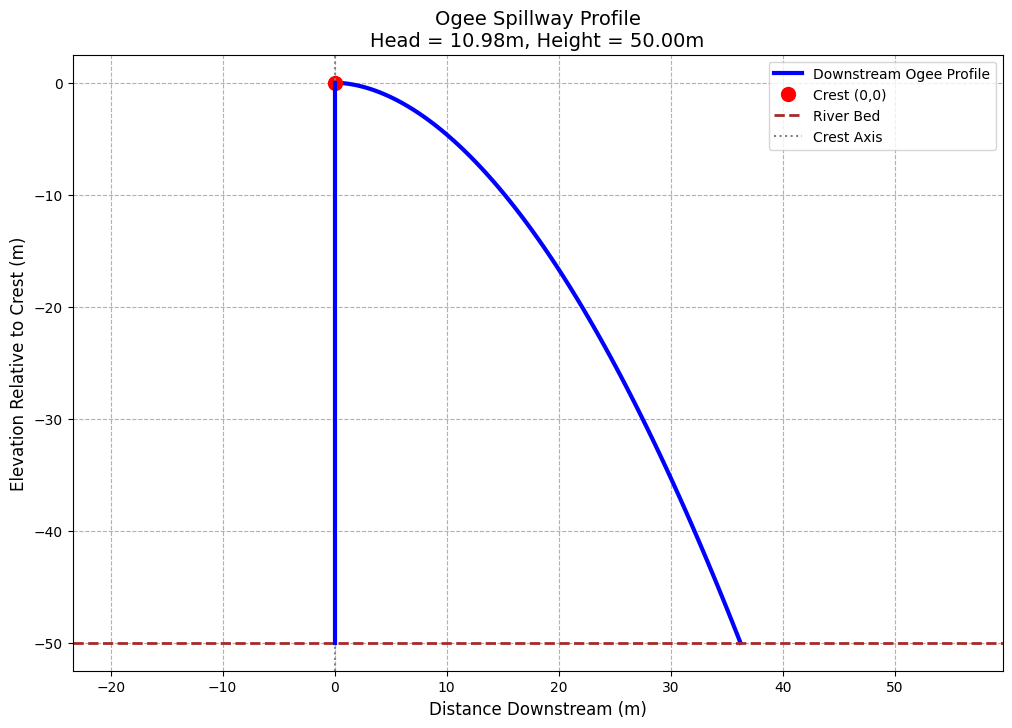

In [3]:
# Generate Spillway Ogee Curve Geometry (x and y coordinates)
import numpy as np
import matplotlib.pyplot as plt

# WES Standard Ogee Profile Equation:
# X^1.85 = 2.0 * Hd^0.85 * Y
# Where Y is vertical distance from crest (positive downwards in standard, we plot negative)

K = 2.0 * math.pow(design_head, 0.85)

# Calculate X range up to the toe (intersection with river bed at y = -spillway_height)
# spillway_height = X^1.85 / K  => X = (spillway_height * K)^(1/1.85)
x_toe = math.pow(spillway_height * K, 1.0/1.85)

# Generate points
x_vals = np.linspace(0, x_toe, 100)
y_vals = - (np.power(x_vals, 1.85)) / K

print(f"Toe Location: X = {x_toe:.2f} m, Y = {-spillway_height:.2f} m")

# Plotting
plt.figure(figsize=(12, 8))
plt.plot(x_vals, y_vals, label='Downstream Ogee Profile', linewidth=3, color='blue')

# Plot setup details
plt.plot([0], [0], 'ro', markersize=10, label='Crest (0,0)')
plt.axhline(-spillway_height, color='brown', linestyle='--', linewidth=2, label='River Bed')
plt.axvline(0, color='gray', linestyle=':', label='Crest Axis')

# Upstream face (Vertical for standard ogee)
plt.plot([0, 0], [0, -spillway_height], color='blue', linewidth=3)

plt.title(f'Ogee Spillway Profile\nHead = {design_head:.2f}m, Height = {spillway_height:.2f}m', fontsize=14)
plt.xlabel('Distance Downstream (m)', fontsize=12)
plt.ylabel('Elevation Relative to Crest (m)', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--')
plt.axis('equal')
plt.show()

In [4]:
# Draw Closed Ogee Spillway Section in AutoCAD
try:
    from myAutoCAD import myAutoCAD
    import array

    # Connect to AutoCAD
    acad = myAutoCAD()

    # Prepare points for LightWeightPolyline (2D flat polyline)
    # Format: [x1, y1, x2, y2, ...]
    poly_points = []

    # 1. Ogee Curve Points (Crest to Toe)
    # We iterate through the generated x_vals and y_vals from the previous cell
    for x, y in zip(x_vals, y_vals):
        poly_points.append(float(x))
        poly_points.append(float(y))

    # 2. Base/Heel Point (Bottom Left)
    # We go from the Toe (approx x_toe, -spillway_height) back to the Heel (0, -spillway_height)
    poly_points.append(0.0)
    poly_points.append(-float(spillway_height))

    # 3. Upstream Face
    # The polyline is closed, so it will automatically draw the segment from 
    # the Heel (0, -spillway_height) back to the start point Crest (0, 0)

    # Create array of doubles for AutoCAD COM interface
    points_array = array.array('d', poly_points)

    # Add LightWeightPolyline to Model Space
    pline = acad.model.AddLightWeightPolyline(points_array)
    pline.Closed = True
    pline.Update()

    print(f"Successfully drew Closed Ogee Spillway Section in AutoCAD.")
    print(f"Layer: {pline.Layer}, Handle: {pline.Handle}")

except ImportError:
    print("Error: 'myAutoCAD' module not found. Please ensure myAutoCAD.py is in the notebook directory.")
except Exception as e:
    print(f"An error occurred communicating with AutoCAD: {e}")

Connecting to AutoCAD...
Connected to: spillway.dwg
Successfully drew Closed Ogee Spillway Section in AutoCAD.
Layer: 0, Handle: 70FE
